# 05. Prepayment Rate Sensitivity & Stress Testing - Freddie Mac SFLLD

Extends the baseline prepayment model (`03_prepayment_modeling.ipynb`), which
found that `original_interest_rate` alone accounted for 76% of feature
importance — strongly suggesting a rate "lock-in" effect. This notebook builds
a more direct "rate spread" feature (original rate vs. prevailing market rate)
and uses it to simulate how prepayment probability responds to interest rate
shocks, addressing the project's originally planned stress-testing component.

## Summary

This notebook extends the baseline prepayment model (`03_prepayment_modeling.ipynb`)
by engineering a "rate spread" feature and using it to simulate interest rate
stress scenarios. Key findings:

- The peak timing of prepayment activity was determined empirically (median
  20 months, mean 23.2 months post-origination) rather than assumed, leading
  to a 24-month reference point for measuring rate spread.
- `rate_spread` (market rate 24 months post-origination minus original rate)
  substantially improved model performance: ROC-AUC rose from 0.747 to 0.814,
  and the feature became the dominant predictor (64.8% importance, vs. 23.7%
  for the raw origination rate it partially replaced).
- Model validation against actual vintage-year prepayment rates showed strong
  alignment overall, with some overprediction (6-8pp) during peak lock-in
  years (2021-2022) — suggesting real borrower behavior may be even "stickier"
  than rate incentives alone would predict.
- Simulating rate shocks (-2pp to +2pp) showed prepayment probability swings
  by up to ~30 percentage points, confirming strong rate sensitivity.
- Breaking this down by vintage year revealed **ceiling and floor effects**:
  2018 loans (higher original rates) are insensitive to further rate declines
  but sensitive to rate increases; 2021-2022 loans (near-record-low original
  rates) show the opposite — largely insensitive to further rate increases,
  but highly sensitive to rate declines, since even a small drop can flip
  their rate spread from lock-in to refinancing incentive.
- **Practical implication:** loans originated during low-rate periods carry
  the greatest "convexity risk" — their prepayment behavior is most sensitive
  to future rate declines, a risk mortgage investors specifically hedge against.

## 1. Setup & Imports

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import load_orig_data, clean_orig_data, load_svcg_data, build_prepayment_dataset, get_prepayment_labels, calculate_rate_spread

## 2. Load Market Mortgage Rate Data (FRED)

Load monthly average 30-year fixed mortgage rates (Freddie Mac PMMS, via FRED)
to construct a "rate spread" feature — the difference between a loan's
original interest rate and the prevailing market rate at a later point in
time. This captures refinancing incentive more directly than the raw
origination rate alone.

In [2]:
market_rate = pd.read_csv('../data/raw/fred/MORTGAGE30US.csv')

# Rename variables
market_rate = market_rate.rename(columns={
    'observation_date': 'rate_date',
    'MORTGAGE30US': 'market_rate'
})
market_rate['rate_date'] = pd.to_datetime(market_rate['rate_date'])

market_rate['year_month'] = market_rate['rate_date'].dt.strftime('%Y%m').astype(int)

market_rate.head()

,rate_date,market_rate,year_month
0,2018-01-01,4.03,201801
1,2018-02-01,4.33,201802
2,2018-03-01,4.44,201803
3,2018-04-01,4.47,201804
4,2018-05-01,4.59,201805


## 3. Determine Rate-Spread Reference Point Empirically

Before choosing a fixed month to measure the rate spread, examine the actual
distribution of loan age at prepayment — i.e., how many months after
origination do prepaid loans typically terminate? This provides a data-driven
basis for selecting the reference point, rather than relying purely on
industry convention.

count    109653.000000
mean         23.242018
std          14.779200
min           0.000000
25%          12.000000
50%          20.000000
75%          31.000000
max          91.000000
Name: loan_age, dtype: float64


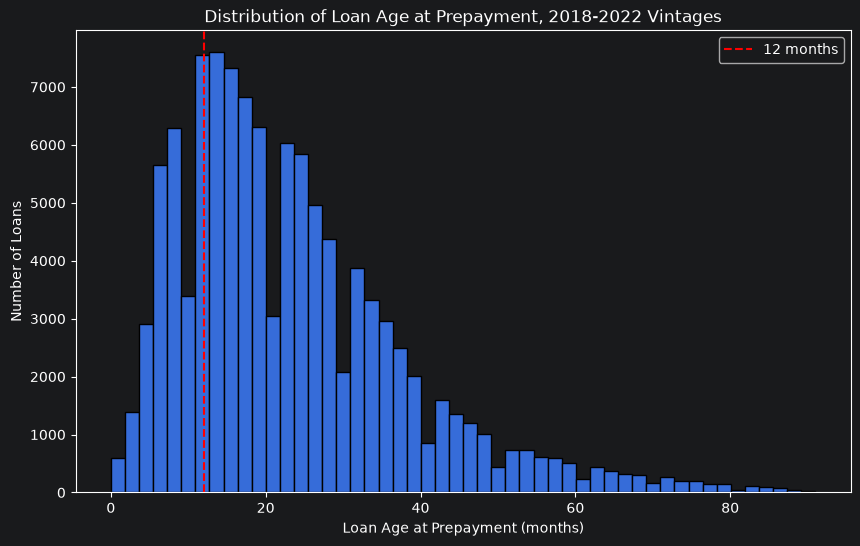

In [3]:
years = range(2018, 2023)

prepay_timing_list = []
for year in years:
    df_svcg = load_svcg_data(year)
    prepaid_records = df_svcg[df_svcg['zero_balance_code'] == 1]
    prepay_timing_list.append(prepaid_records[['loan_sequence_number', 'loan_age']])

prepay_timing = pd.concat(prepay_timing_list, ignore_index=True)

print(prepay_timing['loan_age'].describe())

plt.figure(figsize=(10, 6))
plt.hist(prepay_timing['loan_age'], bins=50, edgecolor='black')
plt.xlabel('Loan Age at Prepayment (months)')
plt.ylabel('Number of Loans')
plt.title('Distribution of Loan Age at Prepayment, 2018-2022 Vintages')
plt.axvline(x=12, color='red', linestyle='--', label='12 months')
plt.legend()
plt.show()

### Empirical Basis for Reference Point Selection

The distribution of loan age at prepayment shows a median of 20 months and
mean of 23.2 months (2018-2022 vintages), indicating that prepayment activity
is concentrated around the 2-year mark rather than the 12-month point
initially assumed based on industry convention. Based on this, **24 months**
is used as the reference point for calculating rate spread — close to both
the mean and a clean, interpretable "2-year" framing.

## 4. Calculate Rate Spread at 24 Months

For each loan, calculate the market mortgage rate 24 months after origination
(the empirically observed peak prepayment timing), then compute the rate
spread as `market_rate_24mo - original_interest_rate`. A larger positive
spread indicates the loan's original rate is well below the prevailing market
rate — signaling strong lock-in (low refinancing incentive). A negative spread
means market rates fell below the original rate, creating refinancing incentive.

In [4]:
# Test on 2018 data first
df_orig_2018 = load_orig_data(2018)
df_orig_2018 = clean_orig_data(df_orig_2018)

df_with_spread_2018 = calculate_rate_spread(df_orig_2018, market_rate)

print(df_with_spread_2018[['loan_sequence_number', 'first_payment_date', 'original_interest_rate', 'reference_year_month', 'market_rate', 'rate_spread']].head())
print(df_with_spread_2018['rate_spread'].isna().sum())

  loan_sequence_number  first_payment_date  original_interest_rate  \
0         F18Q10000028              201803                    4.50   
1         F18Q10000052              201803                    3.25   
2         F18Q10000084              201803                    4.00   
3         F18Q10000117              201803                    3.25   
4         F18Q10000140              201803                    3.75   

   reference_year_month  market_rate  rate_spread  
0                202003         3.45        -1.05  
1                202003         3.45         0.20  
2                202003         3.45        -0.55  
3                202003         3.45         0.20  
4                202003         3.45        -0.30  
0


### Interpreting Rate Spread

`rate_spread = market_rate_24mo - original_interest_rate`

- **Negative spread**: market rate fell below the loan's original rate →
  strong refinancing incentive (borrower could get a better rate).
- **Positive spread**: market rate rose above the loan's original rate →
  lock-in effect, little incentive to refinance.

All 2018 vintage loans matched successfully (0 unmatched), confirming the
24-month reference point falls within the available FRED market rate range.

In [5]:
years = range(2018,2023)

df_spread_list = []

for year in years:
    df_orig = load_orig_data(year)
    df_orig = clean_orig_data(df_orig)
    df_with_spread = calculate_rate_spread(df_orig, market_rate)
    df_with_spread['vintage_year'] = year
    df_spread_list.append(df_with_spread)

df_all_spread = pd.concat(df_spread_list, ignore_index=True)

print(df_all_spread.shape)
print(df_all_spread['rate_spread'].isna().sum())
print(df_all_spread.groupby('vintage_year')['rate_spread'].mean())

(250000, 40)
0
vintage_year
2018   -1.754308
2019   -1.144530
2020    2.597700
2021    3.900378
2022    1.664092
Name: rate_spread, dtype: float64


### Rate Spread Trend Confirms Lock-In Pattern

Average rate spread flips from negative (2018: -1.75, 2019: -1.14 — market
rates fell, creating refinancing incentive) to sharply positive (2021: +3.90
— market rates rose well above original rates, creating strong lock-in). This
directly explains the previously observed decline in prepayment rates across
these vintages: 2018-2019 loans had strong financial incentive to refinance,
while 2020-2022 loans did not.

## 5. Retrain Prepayment Model with Rate Spread Feature

Merge the rate spread feature into the modeling dataset (2018-2022 vintages,
consistent with the existing prepayment label window) and retrain a Random
Forest model with `rate_spread` added to the original feature set. Compare
ROC-AUC against the baseline model (without rate spread) from
`03_prepayment_modeling.ipynb`.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Merge in prepay_flag (reuse the existing prepayment label logic)
prepay_labels_all = []
for year in years:
    prepay_labels_all.append(get_prepayment_labels(year))
prepay_labels_all_df = pd.concat(prepay_labels_all, ignore_index=True)

df_spread_model = df_all_spread.merge(prepay_labels_all_df, on='loan_sequence_number', how='left')

# Add rate_spread to the existing feature set
features_v2 = [
    'credit_score', 'original_cltv', 'original_dti', 'original_upb',
    'original_ltv', 'original_interest_rate', 'original_loan_term',
    'number_of_borrowers', 'number_of_units', 'rate_spread'
]

target = 'prepay_flag'

df_baseline_v2 = df_spread_model[features_v2 + [target]].dropna()

X_v2 = df_baseline_v2[features_v2]
y_v2 = df_baseline_v2[target]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

rf_model_v2 = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced', random_state=42
)
rf_model_v2.fit(X_train_v2, y_train_v2)

rf_pred_proba_v2 = rf_model_v2.predict_proba(X_test_v2)[:, 1]

print(f"With rate_spread - ROC-AUC: {roc_auc_score(y_test_v2, rf_pred_proba_v2):.4f}")
print(f"Without rate_spread (original) - ROC-AUC: 0.7469")


With rate_spread - ROC-AUC: 0.8141
Without rate_spread (original) - ROC-AUC: 0.7469


### Note: Random Forest Only (No Logistic Regression Re-Comparison)

This iteration uses Random Forest only, since it already substantially
outperformed Logistic Regression in the baseline comparison (§03). The goal
here is to test whether the engineered `rate_spread` feature improves the
already-stronger model, not to re-run the LR-vs-RF comparison. Random Forest
also does not require feature scaling, since tree-based splits are invariant
to the absolute scale of numeric features.

## 6. Feature Importance Comparison

Examine whether `rate_spread` outranks `original_interest_rate` in feature
importance, which would confirm that the engineered spread captures
refinancing incentive more directly than the raw origination rate alone.

rate_spread               0.648100
original_interest_rate    0.236627
original_upb              0.048683
credit_score              0.016908
original_cltv             0.014855
original_ltv              0.013226
original_dti              0.009443
original_loan_term        0.007021
number_of_units           0.002663
number_of_borrowers       0.002472
dtype: float64


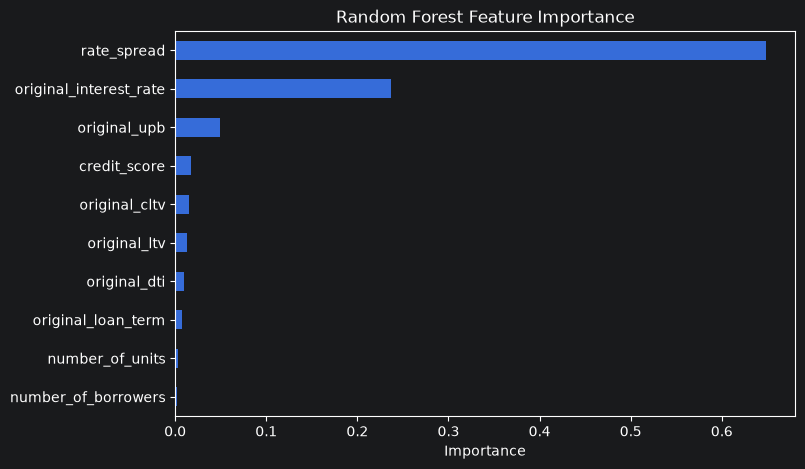

In [7]:
importances_v2 = pd.Series(rf_model_v2.feature_importances_, index=features_v2).sort_values(ascending=False)
print(importances_v2)

plt.figure(figsize=(8, 5))
importances_v2.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

### Rate Spread Substantially Improves Prepayment Prediction

Adding `rate_spread` (market rate 24 months post-origination minus original
rate) improved ROC-AUC from 0.747 to 0.814 — a meaningful gain. Feature
importance confirms the hypothesis: `rate_spread` now accounts for 64.8% of
predictive signal, while `original_interest_rate`'s importance drops from
76.0% to 23.7%. This indicates the two features carry overlapping information
about refinancing incentive, but `rate_spread` captures it far more directly
and efficiently — the model responds more to *how favorable a loan's rate is
relative to the current market* than to the raw rate itself.

## 7. Stress Test: Simulating Interest Rate Shocks

Using the trained Random Forest model, simulate how prepayment probability
would respond to hypothetical interest rate shocks by shifting `rate_spread`
for all test-set loans by a fixed amount (holding all other features constant),
then re-predicting. A shift of -1.0 represents market rates falling 1
percentage point (increasing refinance incentive); +1.0 represents rates
rising 1 percentage point (increasing lock-in).

   rate_shock  avg_predicted_prepay_prob
0          -2                   0.651767
1          -1                   0.568103
2           0                   0.481851
3           1                   0.424387
4           2                   0.356001


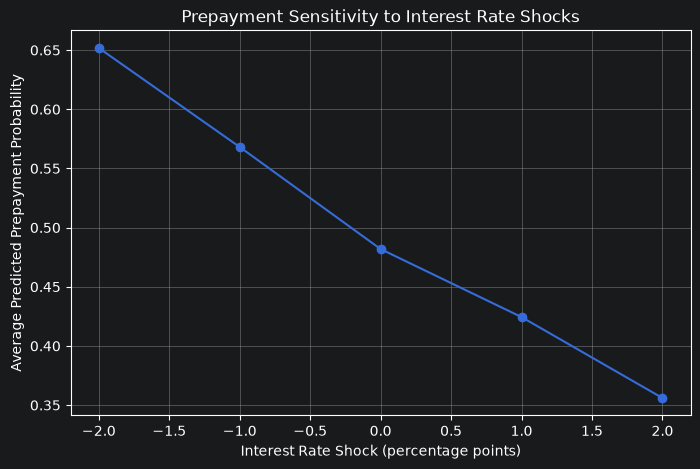

In [8]:
#Simulate rate shocks: shifting rate_spread by the amounts (percentage points)
rate_shocks = [-2,-1,0,1,2]

stress_test_results = []

for shock in rate_shocks:
    X_test_shocked = X_test_v2.copy()
    X_test_shocked['rate_spread'] = X_test_shocked['rate_spread'] + shock

    shocked_proba = rf_model_v2.predict_proba(X_test_shocked)[:,1]

    stress_test_results.append({
        'rate_shock': shock,
        'avg_predicted_prepay_prob': shocked_proba.mean()
    })

stress_test_df = pd.DataFrame(stress_test_results)
print(stress_test_df)

plt.figure(figsize=(8, 5))
plt.plot(stress_test_df['rate_shock'], stress_test_df['avg_predicted_prepay_prob'], marker='o')
plt.xlabel('Interest Rate Shock (percentage points)')
plt.ylabel('Average Predicted Prepayment Probability')
plt.title('Prepayment Sensitivity to Interest Rate Shocks')
plt.grid(True)
plt.show()

### Stress Test Results: Strong Sensitivity to Rate Shocks

Predicted prepayment probability responds sharply and monotonically to
simulated rate shocks: a 2-percentage-point rate decline raises average
predicted prepayment probability from 48.2% to 65.2% (+17.0pp), while a
2-percentage-point rate increase lowers it to 35.6% (-12.6pp). This ~30
percentage point swing across a 4-point rate range confirms that prepayment
behavior in this portfolio is highly sensitive to the interest rate
environment — consistent with the lock-in effect identified earlier, and
demonstrating the kind of rate-shock sensitivity analysis relevant to
mortgage servicing risk management (e.g., estimating prepayment speed changes
under different rate environments).

## 8. Validate Model Against Observed Patterns

Before breaking the stress test down by vintage year, sanity-check the
model's baseline (zero-shock) predictions against the actual observed
prepayment rates per vintage. This confirms the model's predictions are
grounded in reality before using it for hypothetical scenario analysis.

In [9]:
# Re-include vintage_year for post-hoc analysis (not used as a model feature)
df_baseline_v2_with_year = df_spread_model[features_v2 + [target, 'vintage_year']].dropna()

X_v2 = df_baseline_v2_with_year[features_v2]
y_v2 = df_baseline_v2_with_year[target]

# Re-run the same split (same random_state ensures identical rows to before)
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

# Retrieve vintage_year for the test set using the preserved index
vintage_test = df_baseline_v2_with_year.loc[X_test_v2.index, 'vintage_year']

# Baseline (zero-shock) predicted probability
baseline_proba = rf_model_v2.predict_proba(X_test_v2)[:, 1]

# Compare predicted vs. actual by vintage year
validation_df = pd.DataFrame({
    'vintage_year': vintage_test.values,
    'predicted_prob': baseline_proba,
    'actual_prepay': y_test_v2.values
})

comparison = validation_df.groupby('vintage_year').agg(
    avg_predicted=('predicted_prob', 'mean'),
    actual_rate=('actual_prepay', 'mean')
)
print(comparison)

              avg_predicted  actual_rate
vintage_year                            
2018               0.802506     0.788979
2019               0.758913     0.692493
2020               0.376868     0.378133
2021               0.228548     0.167541
2022               0.241552     0.164479


### Model Validation Against Actual Rates

Comparing baseline (zero-shock) predicted probabilities against actual
observed prepayment rates by vintage year shows generally strong alignment,
particularly for 2018 (80.3% predicted vs. 78.9% actual) and 2020 (37.7% vs.
37.8%). The model somewhat overpredicts for 2019, 2021, and 2022 (by 6-8
percentage points), most notably during the peak lock-in years (2021-2022).
This may suggest that actual borrower behavior during periods of strong
lock-in incentive is even "stickier" than the model captures — potential
additional frictions (e.g., refinancing transaction costs, tighter credit
conditions) beyond what `rate_spread` and other features account for.

Overall, this validation supports using the model for directional stress
testing (i.e., examining how prepayment responds to rate changes), while
noting that absolute predicted levels should be interpreted with some caution,
particularly during high-lock-in periods.

## 9. Stress Test by Vintage Year

Repeat the interest rate shock simulation separately for each vintage year,
to see whether prepayment sensitivity to rate shocks differs depending on the
loan's original rate environment (e.g., loans originated at very low rates
during 2020-2021 may respond differently than loans from higher-rate periods).

vintage_year      2018      2019      2020      2021      2022
rate_shock                                                    
-2            0.808500  0.793709  0.561403  0.452445  0.640861
-1            0.811297  0.793002  0.482237  0.331296  0.421435
 0            0.802506  0.758913  0.376868  0.228548  0.241552
 1            0.727773  0.660967  0.281007  0.218178  0.232922
 2            0.545207  0.527348  0.235982  0.223779  0.246772


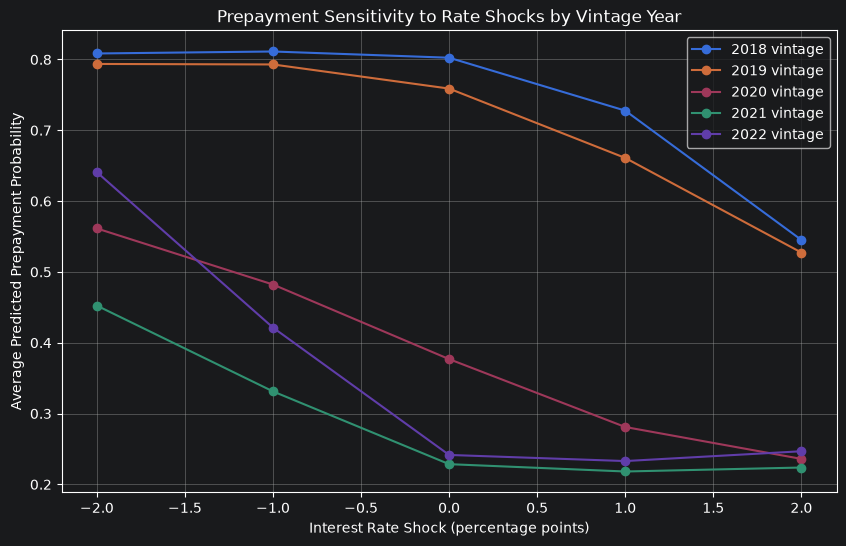

In [10]:
rate_shocks = [-2, -1, 0, 1, 2]

stress_by_vintage = []

for year in sorted(validation_df['vintage_year'].unique()):
    year_mask = vintage_test.values == year
    X_test_year = X_test_v2[year_mask]

    for shock in rate_shocks:
        X_shocked = X_test_year.copy()
        X_shocked['rate_spread'] = X_shocked['rate_spread'] + shock

        shocked_proba = rf_model_v2.predict_proba(X_shocked)[:, 1]

        stress_by_vintage.append({
            'vintage_year': year,
            'rate_shock': shock,
            'avg_predicted_prepay_prob': shocked_proba.mean()
        })

stress_by_vintage_df = pd.DataFrame(stress_by_vintage)
stress_pivot = stress_by_vintage_df.pivot(index='rate_shock', columns='vintage_year', values='avg_predicted_prepay_prob')
print(stress_pivot)

plt.figure(figsize=(10, 6))
for year in stress_pivot.columns:
    plt.plot(stress_pivot.index, stress_pivot[year], marker='o', label=f'{year} vintage')
plt.xlabel('Interest Rate Shock (percentage points)')
plt.ylabel('Average Predicted Prepayment Probability')
plt.title('Prepayment Sensitivity to Rate Shocks by Vintage Year')
plt.legend()
plt.grid(True)
plt.show()

### Vintage-Specific Sensitivity: Ceiling and Floor Effects

Rate shock sensitivity varies meaningfully by vintage year, revealing
ceiling/floor effects driven by each vintage's original rate environment:

- **2018 vintage** (higher original rates): Already has high baseline
  prepayment probability (~80%) and is largely insensitive to further rate
  declines (a "ceiling effect" — most borrowers with refinancing incentive
  have already acted), but remains sensitive to rate increases.
- **2021-2022 vintages** (historically low original rates): Show the opposite
  pattern — a "floor effect" where further rate increases barely reduce an
  already-low prepayment probability (already deeply locked-in), but are
  highly sensitive to rate *declines*, since even a modest drop could restore
  refinancing incentive (e.g., 2022: a -2pp shock nearly triples predicted
  prepayment probability, from 24.2% to 64.1%).

**Practical implication:** loans originated during low-rate periods carry the
greatest "convexity risk" from a servicer's perspective — their prepayment
behavior is most sensitive to future rate declines, which is exactly the
scenario mortgage investors care most about hedging against.

### Clarifying Note: Why 2022 Shows the Largest Response to Rate Declines

This sensitivity is driven by proximity to the spread's zero-crossing point,
not by the absolute level of original rates. The 2022 vintage had the
smallest average rate spread among 2020-2022 (+1.66, vs. +2.60 for 2020 and
+3.90 for 2021) — meaning it was already closest to the tipping point where
market rates would fall below the original rate and restore refinancing
incentive. A -2pp shock pushes 2022's average spread negative (-0.34), while
2020 and 2021 remain positive (still locked-in) even after the same shock.
This illustrates that the model responds to the *relative* gap between
original and market rates, not the absolute rate level itself.